In [1]:
#Import libraries that are required for the creation of the machine learning model
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import os

In [2]:
'''
Russell Larkin
08 June 2025
Project 2 - Bayesian Classification
DATA 430 6380
Professor Yamil Guevara
'''

'\nRussell Larkin\n08 June 2025\nProject 2 - Bayesian Classification\nDATA 430 6380\nProfessor Yamil Guevara\n'

In [3]:
# Check if the file exists in the current directory
print(f"Current working directory: {os.getcwd()}")

file_name = "Covid Dataset.csv"
if os.path.exists(file_name):
    print(f"'{file_name}' found in the current directory.")
    covid_df = pd.read_csv(file_name)
    print("File loaded successfully.")
    print(covid_df.head())
else:
    print(f"Error: '{file_name}' not found in the current directory.")
    print("Please ensure the file is in the correct directory or provide the correct path.")

Current working directory: /content
'Covid Dataset.csv' found in the current directory.
File loaded successfully.
  Breathing Problem Fever Dry Cough Sore throat Running Nose Asthma  \
0               Yes   Yes       Yes         Yes          Yes     No   
1               Yes   Yes       Yes         Yes           No    Yes   
2               Yes   Yes       Yes         Yes          Yes    Yes   
3               Yes   Yes       Yes          No           No    Yes   
4               Yes   Yes       Yes         Yes          Yes     No   

  Chronic Lung Disease Headache Heart Disease Diabetes  ... Fatigue   \
0                   No       No            No      Yes  ...      Yes   
1                  Yes      Yes            No       No  ...      Yes   
2                  Yes      Yes            No      Yes  ...      Yes   
3                   No       No           Yes      Yes  ...       No   
4                  Yes      Yes           Yes      Yes  ...       No   

  Gastrointestinal  Abroad

In [4]:
#Checking df.info()

covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Breathing Problem                        5434 non-null   object
 1   Fever                                    5434 non-null   object
 2   Dry Cough                                5434 non-null   object
 3   Sore throat                              5434 non-null   object
 4   Running Nose                             5434 non-null   object
 5   Asthma                                   5434 non-null   object
 6   Chronic Lung Disease                     5434 non-null   object
 7   Headache                                 5434 non-null   object
 8   Heart Disease                            5434 non-null   object
 9   Diabetes                                 5434 non-null   object
 10  Hyper Tension                            5434 non-null   obj

In [5]:
# Checking unique values

covid_df.nunique()

,0
Breathing Problem,2
Fever,2
Dry Cough,2
Sore throat,2
Running Nose,2
Asthma,2
Chronic Lung Disease,2
Headache,2
Heart Disease,2
Diabetes,2


In [6]:
# Remove columns with only one unique value

covid_df = covid_df.drop(columns=['Wearing Masks', 'Sanitization from Market'])

In [7]:
# Transform to int values

covid_df = covid_df.replace({'Yes': 1, 'No': 0})
covid_df.head()

<ipython-input-7-d9fbce85bb6b>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  covid_df = covid_df.replace({'Yes': 1, 'No': 0})


,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,Hyper Tension,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,COVID-19
0,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,1,1,1
1,1,1,1,1,0,1,1,1,0,0,0,1,0,0,0,1,1,0,1
2,1,1,1,1,1,1,1,1,0,1,0,1,1,1,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,0,0,0,1,0,1,1,0,1
4,1,1,1,1,1,0,1,1,1,1,1,0,1,0,1,0,1,0,1


In [8]:
# Check that everything now is of type int

covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        5434 non-null   int64
 1   Fever                                    5434 non-null   int64
 2   Dry Cough                                5434 non-null   int64
 3   Sore throat                              5434 non-null   int64
 4   Running Nose                             5434 non-null   int64
 5   Asthma                                   5434 non-null   int64
 6   Chronic Lung Disease                     5434 non-null   int64
 7   Headache                                 5434 non-null   int64
 8   Heart Disease                            5434 non-null   int64
 9   Diabetes                                 5434 non-null   int64
 10  Hyper Tension                            5434 non-null   int64
 11  Fati

In [9]:
# There are four times as many 'Yes' COVID-19 as there are 'No'. 'No' is the minority class.

covid_df['COVID-19'].value_counts()

,count
COVID-19,
1,4383
0,1051


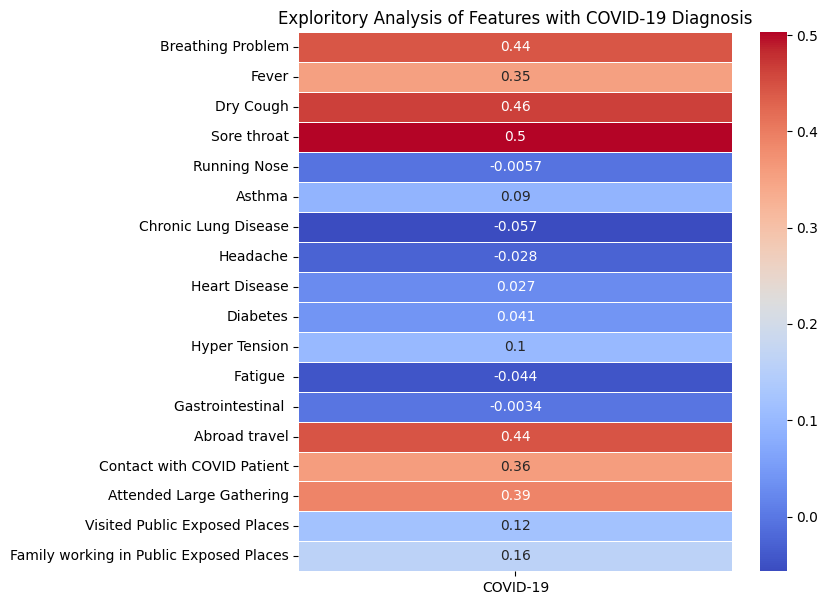

In [10]:
# Exploritory analysis of Target('COVID-19') and Features(variables)

correlation_matrix = covid_df.corr()
target_correlation = correlation_matrix[['COVID-19']].drop('COVID-19')

plt.figure(figsize=(7, 7))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Exploritory Analysis of Features with COVID-19 Diagnosis')
plt.show()

In [11]:
# Created a count of related symptom-related "Yes" responses

symptom_cols = [
    'Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat'
]
covid_df['Symptom_Score'] = covid_df[symptom_cols].sum(axis=1)

In [12]:
# Adding exposure related "Yes" into a single score.

exposure_cols = [
    'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering'
]
covid_df['Exposure_Score'] = covid_df[exposure_cols].sum(axis=1)

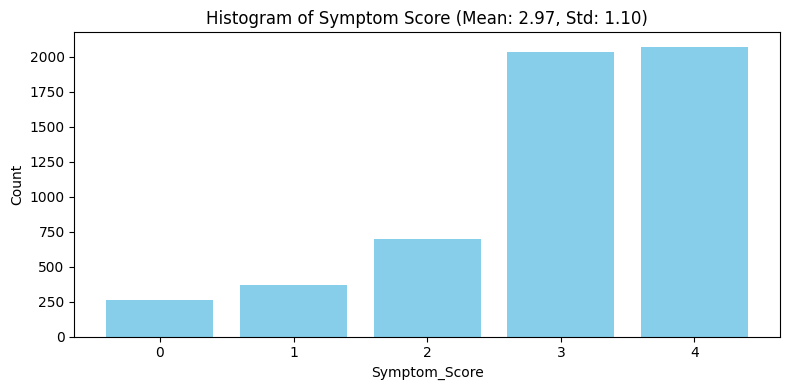

In [13]:
# Distribution of Symptom_Score
SD = covid_df['Symptom_Score'].std()
M = covid_df['Symptom_Score'].mean()

plt.figure(figsize=(8,4))
plt.hist(
    covid_df['Symptom_Score'],
    bins=range(0, covid_df['Symptom_Score'].max()+2),
    align='left',
    rwidth=0.8,
    color='skyblue'
)
plt.xlabel('Symptom_Score')
plt.ylabel('Count')
plt.title(f'Histogram of Symptom Score (Mean: {M:.2f}, Std: {SD:.2f})')
plt.xticks(range(0, covid_df['Symptom_Score'].max()+1))
plt.tight_layout()
plt.show()


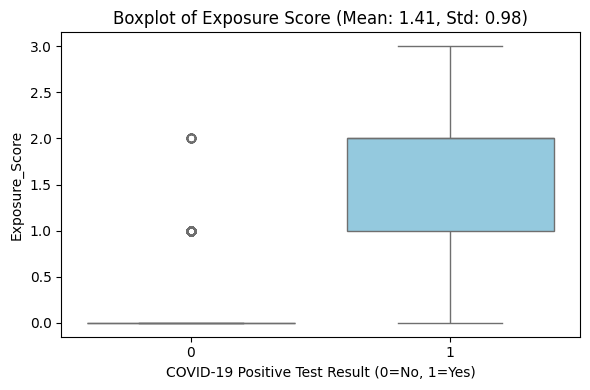

In [14]:
# Exposure_Score by COVID-19 status
SD = covid_df['Exposure_Score'].std()
M = covid_df['Exposure_Score'].mean()

plt.figure(figsize=(6,4))
sns.boxplot(
    x='COVID-19',
    y='Exposure_Score',
    data=covid_df,
    color='skyblue'
)
plt.xlabel('COVID-19 Positive Test Result (0=No, 1=Yes)')
plt.ylabel('Exposure_Score')
plt.title(f'Boxplot of Exposure Score (Mean: {M:.2f}, Std: {SD:.2f})')
plt.tight_layout()
plt.show()


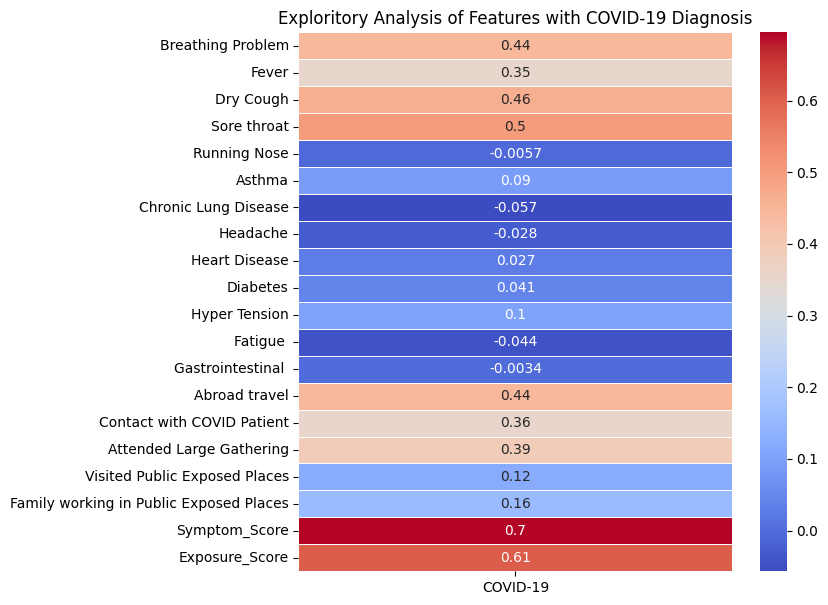

In [15]:
# Exploritory analysis of Target('COVID-19') and Features(variables)

correlation_matrix = covid_df.corr()
target_correlation = correlation_matrix[['COVID-19']].drop('COVID-19')

plt.figure(figsize=(7, 7))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Exploritory Analysis of Features with COVID-19 Diagnosis')
plt.show()

In [16]:
# Dropping different pre-existing conditions, symptoms, and methods of contact didn't
# improve the model.

# drop_preexist = ['Asthma', 'Chronic Lung Disease', 'Headache', 'Heart Disease', 'Diabetes', 'Hyper Tension']
# drop_symptoms = ['Sore throat', 'Running Nose', 'Breathing Problem', 'Fever', 'Dry Cough']
# drop_contact = ['Visited Public Exposed Places', 'Family working in Public Exposed Places', 'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering',]

X = covid_df.drop(columns=['COVID-19'])
y = covid_df['COVID-19']

In [17]:
# This code splits the dataset into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4347, 20) (4347,)
Test set: (1087, 20) (1087,)


In [18]:
# This code rescales the features. Only the features and not the response variable.

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
# This code creates the ML models

from sklearn.naive_bayes import BernoulliNB
BernoulliNB = BernoulliNB()
BernoulliNB.fit(X_train, y_train)

BernoulliNB()

In [20]:
# Tuning the threshold.
y_pred = BernoulliNB.predict(X_test)

# Get predicted probabilities
probs = BernoulliNB.predict_proba(X_test)

# Extract probabilities of class 1 (COVID = Yes)
positive_probs = probs[:, 1]

# 0.5 threshold yielded 0 False negatives. The goal is 0.
threshold = 0.5
y_pred_thresh = (positive_probs >= threshold).astype(int)


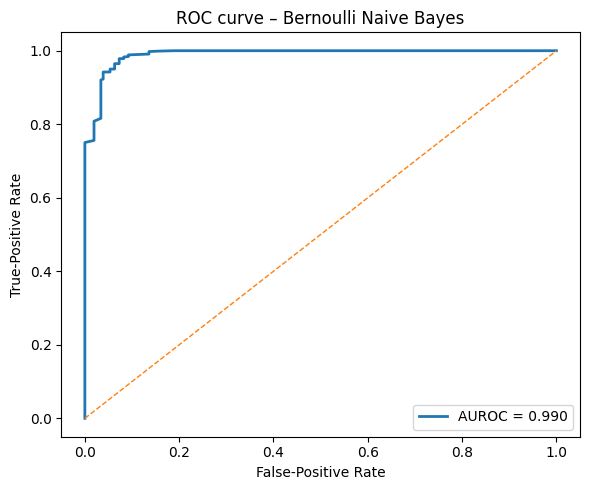

In [21]:
# ROC curve & AUROC
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresh = roc_curve(y_test, positive_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False‑Positive Rate")
plt.ylabel("True‑Positive Rate")
plt.title("ROC curve – Bernoulli Naive Bayes")
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()


<Figure size 640x480 with 0 Axes>

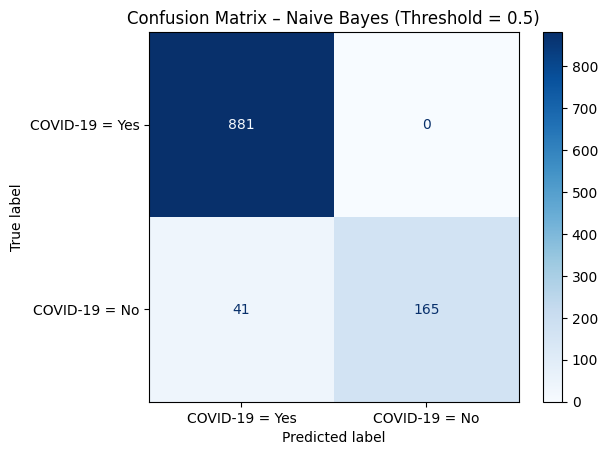

Classification Report – Naive Bayes (Threshold = 0.5)

              precision    recall  f1-score   support

           0       1.00      0.80      0.89       206
           1       0.96      1.00      0.98       881

    accuracy                           0.96      1087
   macro avg       0.98      0.90      0.93      1087
weighted avg       0.96      0.96      0.96      1087



In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred_thresh, labels=[1, 0])

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=['COVID-19 = Yes', 'COVID-19 = No'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix – Naive Bayes (Threshold = {threshold})')
plt.show()

# Classification report
print(f"Classification Report – Naive Bayes (Threshold = {threshold})\n")
print(classification_report(y_test, y_pred_thresh, digits=2))


In [23]:
# 5 fold cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(BernoulliNB, X, y, cv=5, scoring='recall')
print("Recall scores (5-fold):", scores)
print("Mean Recall:          ", scores.mean())

Recall scores (5-fold): [0.95438997 0.99201824 0.94412771 0.8630137  0.98972603]
Mean Recall:           0.9486551287858671


In [24]:
# Compute log loss
from sklearn.metrics import log_loss

y_prob = BernoulliNB.predict_proba(X_test)
ll = log_loss(y_test, y_prob)
print(f"Log Loss: {ll}")

Log Loss: 0.09160399582426006


In [25]:
# Compute accuracy score
ac = accuracy_score(y_test,y_pred)
print(ac)

0.9622815087396505
